# Thales Group Manufacturing Analysis

### Manufacturing Process Health and Operaional Efficiency Analysis in 6G-Enabled Smart Factories

In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashura369/manufacturing-dataset/Thales_Group_Manufacturing.csv")

In [3]:
with pd.option_context('display.max_columns', None):
    display(df.head(10))

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%,Efficiency_Status
0,1/1/2025,0:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low
1,1/1/2025,0:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low
2,1/1/2025,0:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low
3,1/1/2025,0:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium
4,1/1/2025,0:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low
5,1/1/2025,0:05:00,21,Active,80.960,1.386,9.868,48.399,0.575,4.721,147.688,0.897,0.041,Low
6,1/1/2025,0:06:00,39,Active,76.435,4.815,2.617,23.517,2.089,4.895,222.975,0.221,9.032,Low
7,1/1/2025,0:07:00,19,Active,37.670,4.437,7.659,35.451,3.258,4.236,241.457,0.912,0.738,Medium
8,1/1/2025,0:08:00,23,Active,75.547,3.128,2.679,43.648,2.884,7.552,148.458,0.501,11.446,Low
9,1/1/2025,0:09:00,11,Active,56.325,0.648,3.402,23.986,0.564,6.336,281.258,0.805,3.688,Medium


---

<h2 align='center'>Data Cleaning</h2>

#### Checking for Null Values

In [4]:
print(f"TOTAL NULL VALUES : {df.isna().sum().sum()}")

TOTAL NULL VALUES : 0


---

#### Checking For DataTypes and Cell Contents

In [5]:
df.dtypes.reset_index()

,index,0
0,Date,object
1,Timestamp,object
2,Machine_ID,int64
3,Operation_Mode,object
4,Temperature_C,float64
5,Vibration_Hz,float64
6,Power_Consumption_kW,float64
7,Network_Latency_ms,float64
8,Packet_Loss_%,float64
9,Quality_Control_Defect_Rate_%,float64


Observation : <br>
- `Date` : change it to date datatype
- `Timestamp` : change it to time datatype
- `Operation_Mode` : change it to string datatype
- `Efficiency_Status` : change it to string datatype

---

#### Changing The Datatypes For Date and Time

In [6]:
date = df['Date'].str.replace('-','/')

In [7]:
df['Date'] = date.copy()

In [8]:
# Storing date as datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Storing time as time format only (not datetime format)
time = pd.to_datetime(df['Timestamp'], format='mixed')
df['Timestamp'] = time - time.dt.normalize()

#### Changing Datatypes of r `Operation_Mode`, and `Efficiency_Status`

In [9]:
df['Operation_Mode'] = df['Operation_Mode'].astype(object)
df['Efficiency_Status'] = df['Efficiency_Status'].astype(object)

In [10]:
df.dtypes.reset_index()

,index,0
0,Date,datetime64[ns]
1,Timestamp,timedelta64[ns]
2,Machine_ID,int64
3,Operation_Mode,object
4,Temperature_C,float64
5,Vibration_Hz,float64
6,Power_Consumption_kW,float64
7,Network_Latency_ms,float64
8,Packet_Loss_%,float64
9,Quality_Control_Defect_Rate_%,float64


---

<h2 align='center'>Feature Extraction</h2>
<h4 align='center'>Making Clusters Out Of The Existing Features Mentioned Below</h4><br>

1. `Date` : Month, and Days (Make two new features)
2. `Temperature_C` : Optimal, Elevated, Critical  (Clustering)
3. `Vibration_Hz` : Stable, Moderate, Excessive  (Clustering)
4. `Power_Consumption_Kw` : Low load, Standard, Peak  (Clustering)
5. `Network_Latency_ms` : Low, Moderate, High  (Clustering)
6. `Predictive_Maintenance_Score` : Healthy, Monitor, Immediate Action  (Clustering)
7. `Error_Rate_%` : Normal, Warning, Critical  (Clustering)

#### 1. `Date`
Making new features out of Date

In [11]:
months = df['Date'].dt.month_name()
days = df['Date'].dt.day_name()
quarter = df['Date'].dt.quarter

In [12]:
df.columns

Index(['Date', 'Timestamp', 'Machine_ID', 'Operation_Mode', 'Temperature_C',
       'Vibration_Hz', 'Power_Consumption_kW', 'Network_Latency_ms',
       'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
       'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score',
       'Error_Rate_%', 'Efficiency_Status'],
      dtype='object')

In [13]:
df['Month'] = months.copy()
df['Day'] = days.copy()
df['Quarter'] = quarter.copy()

In [14]:
print(f"UNIQUE VALUES IN Month : {df['Month'].unique()}")
print(f"UNIQUE VALUES IN Day : {df['Day'].unique()}")
print(f"UNIQUE VALUES IN Quarter : {df['Quarter'].unique()}")

UNIQUE VALUES IN Month : ['January' 'February' 'March']
UNIQUE VALUES IN Day : ['Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday']
UNIQUE VALUES IN Quarter : [1]


Since quarter only contains one value, we will be deleting it.

In [15]:
df.drop(columns=['Quarter'], inplace=True)

---

#### 2. `Temperature_C`

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df.columns.tolist()

['Date',
 'Timestamp',
 'Machine_ID',
 'Operation_Mode',
 'Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%',
 'Efficiency_Status',
 'Month',
 'Day']

In [18]:
df['Temperature_C'].describe().reset_index()

,index,Temperature_C
0,count,100000.000000
1,mean,60.041460
2,std,17.323239
3,min,30.000000
4,25%,45.031500
5,50%,60.033500
6,75%,74.967250
7,max,89.999000


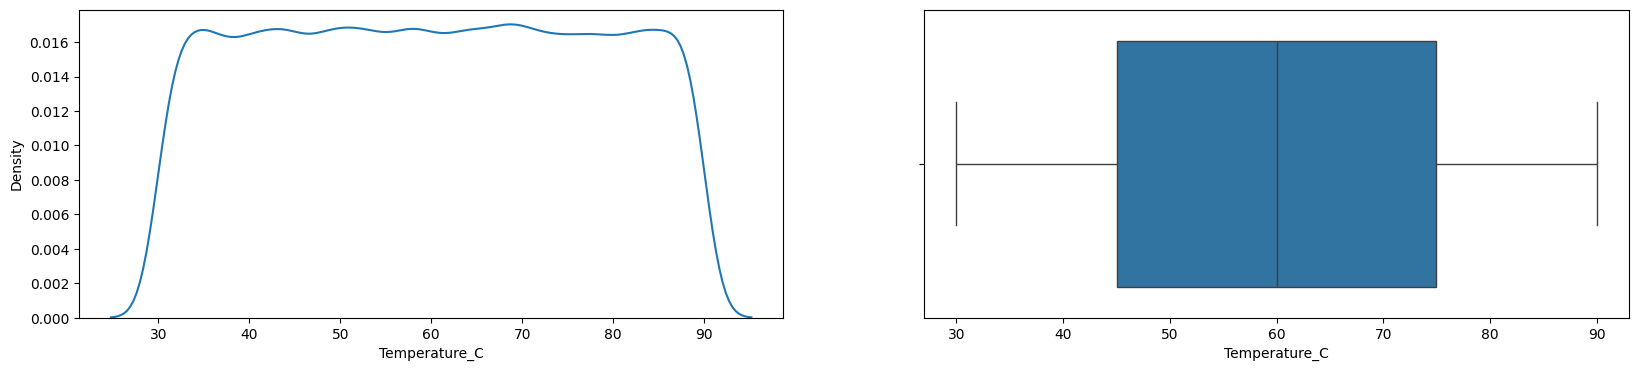

In [19]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(x=df['Temperature_C'])
plt.subplot(122)
sns.boxplot(x=df['Temperature_C'])
plt.show()

Using Percentage Based Binning

In [20]:
max_limit = 100.0
temp = (df['Temperature_C'] / max_limit) * 100

bins  = [0,50,75,90,100]
labels = ['Normal', 'Warning', 'High', 'Critical']
temperature = pd.cut(temp, bins=bins, labels=labels)

In [21]:
df['Temperature'] = temperature.copy()

---

#### 3. `Vibration_Hz`

In [22]:
df['Vibration_Hz'].describe().reset_index()

,index,Vibration_Hz
0,count,100000.000000
1,mean,2.549959
2,std,1.414127
3,min,0.100000
4,25%,1.323000
5,50%,2.549000
6,75%,3.776000
7,max,5.000000


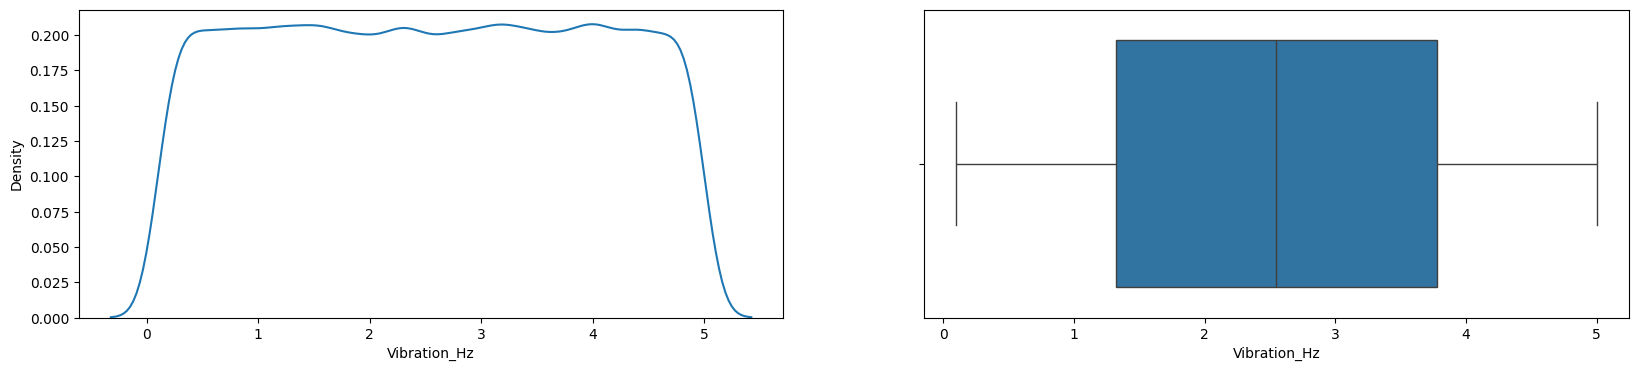

In [23]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(x=df['Vibration_Hz'])
plt.subplot(122)
sns.boxplot(x=df['Vibration_Hz'])
plt.show()

Since the values are btwn 0 and 5, we will be using normal Binning Technique.

In [24]:
bins = [0.0,2.0,4.0,5.0]
labels = ['Stable','Moderate','Critical']

vibration = pd.cut(df['Vibration_Hz'], bins=bins, labels=labels, include_lowest=True)

In [25]:
df['Vibration'] = vibration.copy()

---

#### 4. `Power_Consumption_kW`

In [26]:
df['Power_Consumption_kW'].describe().reset_index()

,index,Power_Consumption_kW
0,count,100000.000000
1,mean,5.745929
2,std,2.451271
3,min,1.500000
4,25%,3.627000
5,50%,5.755000
6,75%,7.860000
7,max,10.000000


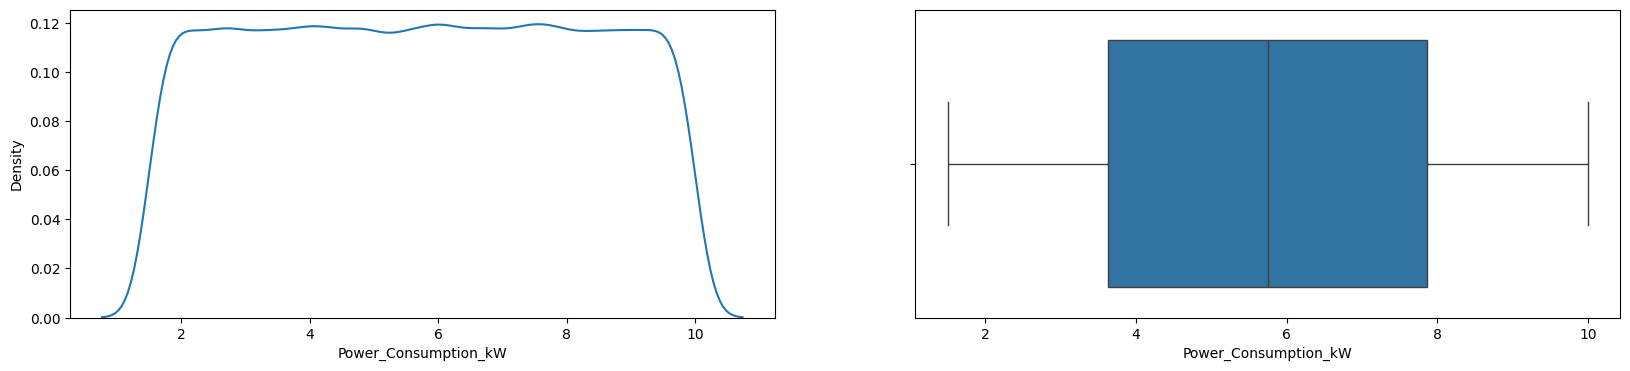

In [27]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(x=df['Power_Consumption_kW'])
plt.subplot(122)
sns.boxplot(x=df['Power_Consumption_kW'])
plt.show()

In [28]:
bins = [1.5, 4.0, 7.5, 10.0]
labels = ['Low Load', 'Normal Load', 'High Load']

power = pd.cut(df['Power_Consumption_kW'], bins=bins, labels=labels, include_lowest=True)

In [29]:
df['Power Consumption'] = power.copy()

---

#### 5. `Network_Latency_ms`

In [30]:
df['Network_Latency_ms'].describe().reset_index()

,index,Network_Latency_ms
0,count,100000.00000
1,mean,25.55562
2,std,14.12076
3,min,1.00000
4,25%,13.35500
5,50%,25.53600
6,75%,37.79625
7,max,50.00000


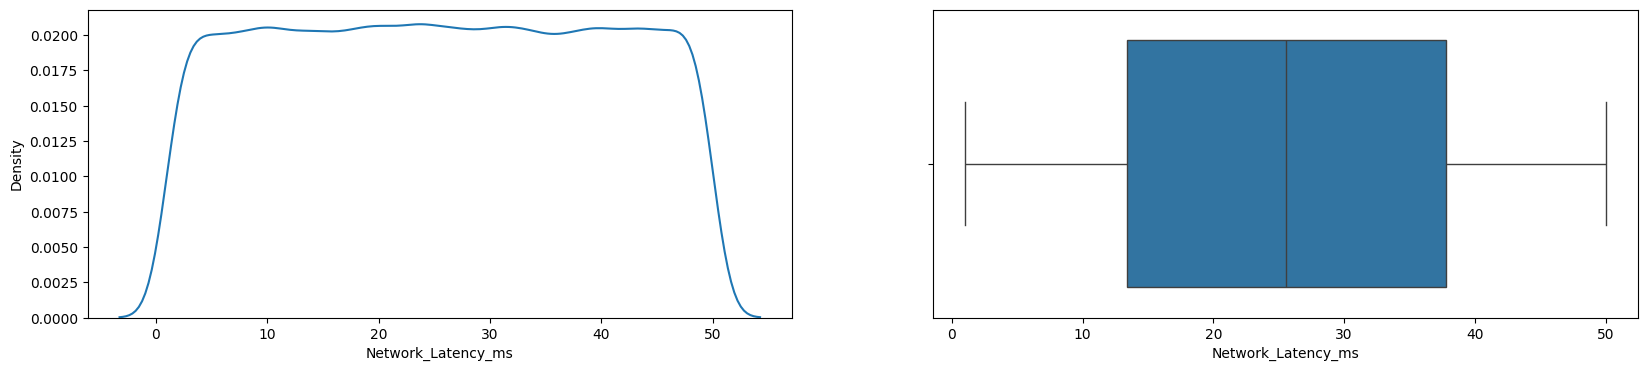

In [31]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(x=df['Network_Latency_ms'])
plt.subplot(122)
sns.boxplot(x=df['Network_Latency_ms'])
plt.show()

In [32]:
bins = [1.0,10.0,35.0,50.0]
labels = ['Low','Moderate','High']

latency = pd.cut(df['Network_Latency_ms'], bins=bins, labels=labels, include_lowest=True)

In [33]:
df['Latency'] = latency.copy()

---

#### 6. `Predictive_Maintenance_Score`

In [34]:
df['Predictive_Maintenance_Score'].describe().reset_index()

,index,Predictive_Maintenance_Score
0,count,100000.000000
1,mean,0.499384
2,std,0.288814
3,min,0.000000
4,25%,0.248000
5,50%,0.499000
6,75%,0.749000
7,max,1.000000


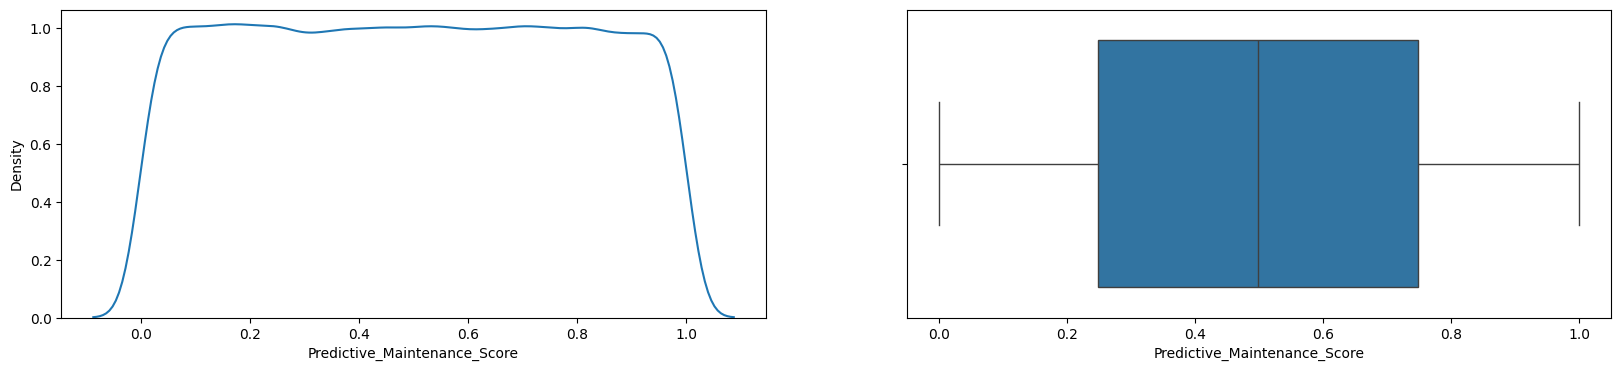

In [35]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(x=df['Predictive_Maintenance_Score'])
plt.subplot(122)
sns.boxplot(x=df['Predictive_Maintenance_Score'])
plt.show()

In [36]:
bins = [0.0, 0.20, 0.70, 1.0]
labels = ['Critical Risk', 'Monitor', 'Healthy']

maintenance = pd.cut(df['Predictive_Maintenance_Score'], bins=bins, labels=labels, include_lowest=True)

In [37]:
df['Maintenance'] = maintenance.copy()

---

#### 7. `Error_Rate_%`

In [38]:
df['Error_Rate_%'].describe().reset_index()

,index,Error_Rate_%
0,count,100000.000000
1,mean,7.504101
2,std,4.335895
3,min,0.000000
4,25%,3.750000
5,50%,7.504000
6,75%,11.273000
7,max,15.000000


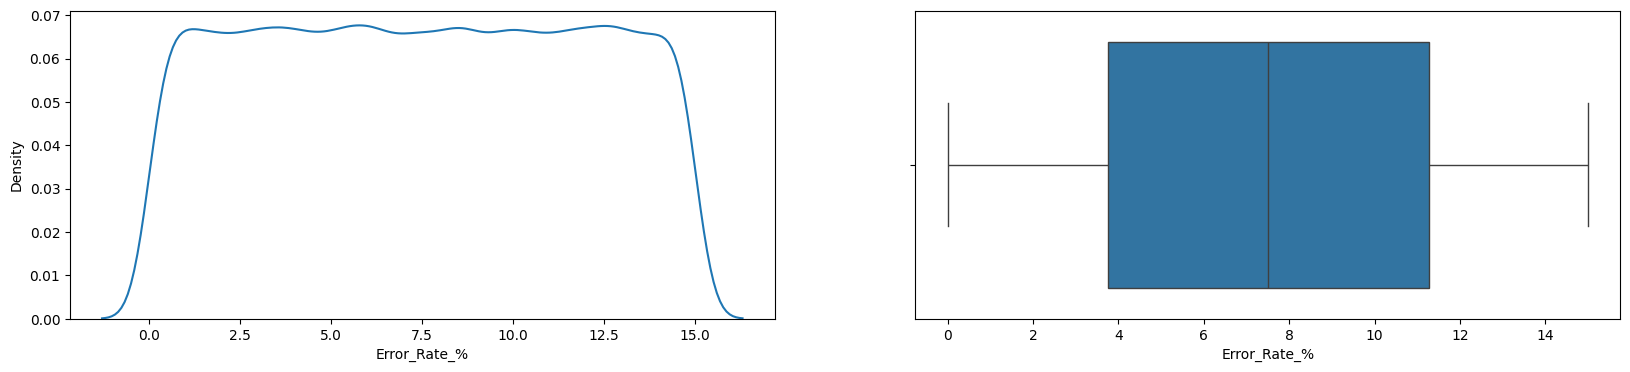

In [39]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(x=df['Error_Rate_%'])
plt.subplot(122)
sns.boxplot(x=df['Error_Rate_%'])
plt.show()

In [40]:
bins = [0.0,5.0,10.0,15.0]
labels = ['Low', 'Moderate', 'High']

errors = pd.cut(df['Error_Rate_%'], bins=bins, labels=labels, include_lowest=True)

In [41]:
df['Error'] = errors.copy()

---

#### 8. `'Packet_Loss_%'`

In [42]:
df['Packet_Loss_%'].describe().reset_index()

,index,Packet_Loss_%
0,count,100000.000000
1,mean,2.493418
2,std,1.443273
3,min,0.000000
4,25%,1.245000
5,50%,2.488000
6,75%,3.741000
7,max,5.000000


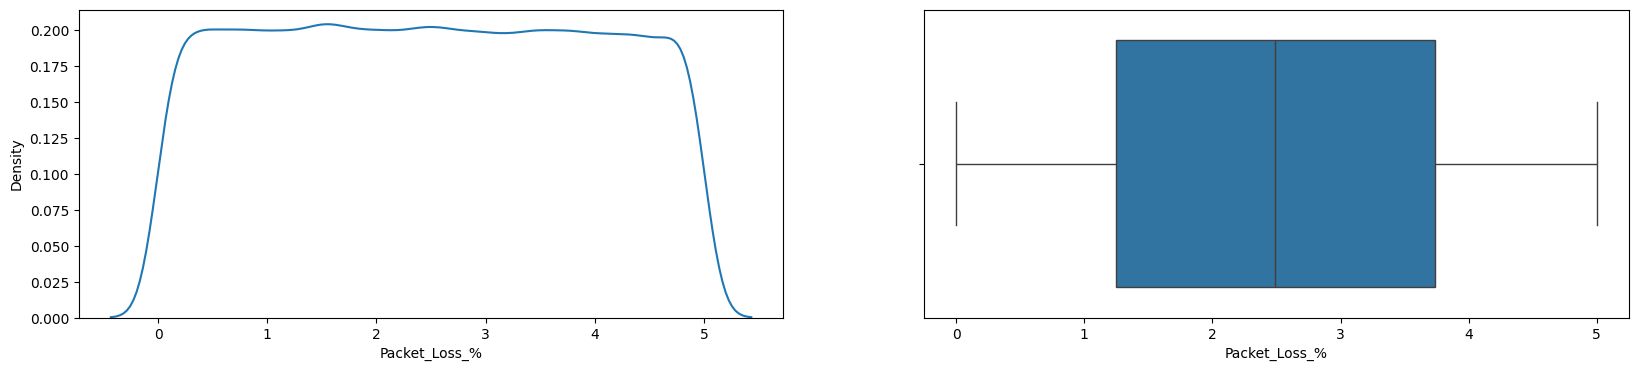

In [43]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(x=df['Packet_Loss_%'])
plt.subplot(122)
sns.boxplot(x=df['Packet_Loss_%'])
plt.show()

In [44]:
bins = [0.0, 1.0, 2.5, 5.0]
labels = ['Negligible', 'Acceptable', 'Critical']

loss = pd.cut(df['Packet_Loss_%'], bins=bins, labels=labels, include_lowest=True)

In [45]:
df['Loss'] = loss.copy()

---

#### 9. `Timestamp`
Making `Hour` feature out of `Timestamp`

In [46]:
df['Hour'] = df['Timestamp'].dt.components['hours']

---

#### 10. `Hour`

In [47]:
bins = [0, 6, 12, 18, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

shifts = pd.cut(df['Hour'], bins=bins, labels=labels, right=False, include_lowest=True)

In [48]:
df['Shifts'] = shifts.copy()

---

In [49]:
df.columns.tolist()

['Date',
 'Timestamp',
 'Machine_ID',
 'Operation_Mode',
 'Temperature_C',
 'Vibration_Hz',
 'Power_Consumption_kW',
 'Network_Latency_ms',
 'Packet_Loss_%',
 'Quality_Control_Defect_Rate_%',
 'Production_Speed_units_per_hr',
 'Predictive_Maintenance_Score',
 'Error_Rate_%',
 'Efficiency_Status',
 'Month',
 'Day',
 'Temperature',
 'Vibration',
 'Power Consumption',
 'Latency',
 'Maintenance',
 'Error',
 'Loss',
 'Hour',
 'Shifts']

In [50]:
temp = {
    'Date' : 'Date',
    'Timestamp' : 'Time',
    'Machine_ID' : "Machine ID",
    'Operation_Mode' : 'Operation Mode',
    'Temperature_C' : 'Temperature (C)',
    'Vibration_Hz' : 'Vibration (Hz)',
    'Power_Consumption_kW' : 'Power Consumption (kW)',
    'Packet_Loss_%' : 'Packet Loss (%)',
    'Quality_Control_Defect_Rate_%' : 'Quality Control Defect Rate (%)',
    'Network_Latency_ms' : 'Latency (ms)',
    'Production_Speed_units_per_hr' : 'Production Speed (units/hr)',
    'Predictive_Maintenance_Score' : 'Maintenance Score',
    'Error_Rate_%' : 'Error Rate (%)',
    'Efficiency_Status' : 'Efficiency_Status',
    'Month' : 'Month',
    'Day' : 'Day',
    'Temperature' : 'Temperature',
    'Vibration' : 'Vibration',
    'Power Consumption' : 'Power Consumption',
    'Latency' : 'Latency',
    'Maintenance' : 'Maintenance',
    'Error' : 'Error',
    'Loss' : 'Loss',
    'Hour' : 'Hour',
    'Shifts' : 'Shifts'
}


df.columns = df.columns.map(temp)



In [51]:
df.columns

Index(['Date', 'Time', 'Machine ID', 'Operation Mode', 'Temperature (C)',
       'Vibration (Hz)', 'Power Consumption (kW)', 'Latency (ms)',
       'Packet Loss (%)', 'Quality Control Defect Rate (%)',
       'Production Speed (units/hr)', 'Maintenance Score', 'Error Rate (%)',
       'Efficiency_Status', 'Month', 'Day', 'Temperature', 'Vibration',
       'Power Consumption', 'Latency', 'Maintenance', 'Error', 'Loss', 'Hour',
       'Shifts'],
      dtype='object')

---

#### Changing The Order Of Features

In [52]:
column_order = [
    # Metadata & Identifiers
    'Machine ID',
    'Date',      
    'Month',
    'Time', 
    'Hour',
    'Day',
    'Operation Mode', 
    'Shifts',
   
    # Sensor & Maintenance Telemetry (Continuous paired with Categorical)
    'Temperature (C)', 'Temperature',
    'Vibration (Hz)', 'Vibration',
    'Power Consumption (kW)', 'Power Consumption',
    'Latency (ms)', 'Latency',
    'Packet Loss (%)', 'Loss',
    'Error Rate (%)', 'Error',
    'Maintenance Score', 'Maintenance',
    
    # Unpaired Metrics & Status
    'Quality Control Defect Rate (%)',
    'Production Speed (units/hr)',
    'Efficiency_Status'
]

df = df[column_order]

---

#### Deleting `Time`
Because it contains only 0 and 1, giving no output.

In [53]:
df.drop(columns='Time', inplace=True)

#### Changing Hour Numbers

In [54]:
df['Hour'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [55]:
df['Hour'] = df['Hour'] + 1

---

In [56]:
with pd.option_context('display.max_columns', None):
    display(df.head(5))

,Machine ID,Date,Month,Hour,Day,Operation Mode,Shifts,Temperature (C),Temperature,Vibration (Hz),Vibration,Power Consumption (kW),Power Consumption,Latency (ms),Latency,Packet Loss (%),Loss,Error Rate (%),Error,Maintenance Score,Maintenance,Quality Control Defect Rate (%),Production Speed (units/hr),Efficiency_Status
0,39,2025-01-01,January,1,Wednesday,Idle,Night,74.138,Warning,3.501,Moderate,8.612,High Load,10.651,Moderate,0.208,Negligible,14.965,High,0.345,Monitor,7.751,477.657,Low
1,29,2025-01-01,January,1,Wednesday,Active,Night,84.265,High,3.356,Moderate,2.269,Low Load,29.112,Moderate,2.228,Acceptable,7.678,Moderate,0.770,Healthy,4.989,398.175,Low
2,15,2025-01-01,January,1,Wednesday,Active,Night,44.280,Normal,2.080,Moderate,6.144,Normal Load,18.357,Moderate,1.639,Acceptable,8.198,Moderate,0.987,Healthy,0.457,108.075,Low
3,43,2025-01-01,January,1,Wednesday,Active,Night,40.569,Normal,0.298,Stable,4.068,Normal Load,29.154,Moderate,1.161,Acceptable,2.741,Low,0.983,Healthy,4.583,329.579,Medium
4,8,2025-01-01,January,1,Wednesday,Idle,Night,75.064,High,0.346,Stable,6.226,Normal Load,34.029,Moderate,4.797,Critical,12.101,High,0.573,Monitor,2.288,159.114,Low


In [57]:
print(f"SHAPE OF DATASET : {df.shape}\n")
print(f"TOTAL CATEGORICAL FEATURE : {len(df.select_dtypes(include='category').columns)} \n{df.select_dtypes(include='category').columns.tolist()}\n")
print(f"TOTAL NUMERICAL FEATURE : {len(df.select_dtypes(include='float').columns)} \n{df.select_dtypes(include='float').columns.tolist()}")

SHAPE OF DATASET : (100000, 24)

TOTAL CATEGORICAL FEATURE : 8 
['Shifts', 'Temperature', 'Vibration', 'Power Consumption', 'Latency', 'Loss', 'Error', 'Maintenance']

TOTAL NUMERICAL FEATURE : 9 
['Temperature (C)', 'Vibration (Hz)', 'Power Consumption (kW)', 'Latency (ms)', 'Packet Loss (%)', 'Error Rate (%)', 'Maintenance Score', 'Quality Control Defect Rate (%)', 'Production Speed (units/hr)']


---

#### Saving The Dataset

In [58]:
df.to_excel('Visualisation Dataset.xlsx', index=False)